Step 1: Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Excel Dataset
file_path = r"D:\Python_workshop\credit_analytics_capstone_dataset.xlsx"
df = pd.read_excel(file_path)

df.head()

,Customer_ID,Age,Gender,Employment_Type,Monthly_Income,Loan_Amount,Loan_Tenure_Months,Interest_Rate,Credit_Utilisation,Past_Loans,Delayed_Payments,EMI,Credit_Default,Observation_Month
0,1,59,Male,Salaried,79921,918004,36,16.90,0.42,1,0,38428.66744,0,2019-05-31
1,2,49,Male,Salaried,41162,209772,24,9.94,0.12,3,5,10478.11140,0,2021-10-31
2,3,35,Male,Self-Employed,48833,122146,12,11.26,0.40,2,5,11324.96997,0,2021-08-31
3,4,28,Male,Salaried,37206,1206130,36,11.89,0.82,4,2,45454.34919,1,2022-11-30
4,5,41,Female,Salaried,71747,996924,24,11.73,0.51,1,1,51283.43210,0,2019-06-30


Step 2: Dataset Overview

In [2]:
df.shape

(8000, 14)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         8000 non-null   int64         
 1   Age                 8000 non-null   int64         
 2   Gender              8000 non-null   object        
 3   Employment_Type     8000 non-null   object        
 4   Monthly_Income      8000 non-null   int64         
 5   Loan_Amount         8000 non-null   int64         
 6   Loan_Tenure_Months  8000 non-null   int64         
 7   Interest_Rate       8000 non-null   float64       
 8   Credit_Utilisation  8000 non-null   float64       
 9   Past_Loans          8000 non-null   int64         
 10  Delayed_Payments    8000 non-null   int64         
 11  EMI                 8000 non-null   float64       
 12  Credit_Default      8000 non-null   int64         
 13  Observation_Month   8000 non-null   datetime64[n

Step 3: Select Business-Relevant Numeric Columns

In [4]:
# defining numeric columns 
numeric_cols = [
    "Age",
    "Monthly_Income",
    "Loan_Amount",
    "Loan_Tenure_Months",
    "Interest_Rate",
    "EMI",
    "Credit_Utilisation",
    "Delayed_Payments"
]

df[numeric_cols].describe()

,Age,Monthly_Income,Loan_Amount,Loan_Tenure_Months,Interest_Rate,EMI,Credit_Utilisation,Delayed_Payments
count,8000.000000,8000.000000,8.000000e+03,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,40.174875,69839.739125,7.712722e+05,35.784000,13.486849,38398.163382,0.499075,2.500750
std,11.191323,28985.177144,4.166000e+05,16.853155,2.605936,30098.583576,0.231317,1.702898
min,21.000000,20036.000000,5.005900e+04,12.000000,9.000000,1275.575050,0.100000,0.000000
25%,31.000000,44054.750000,4.103750e+05,24.000000,11.250000,16643.661262,0.300000,1.000000
50%,40.000000,70363.500000,7.721690e+05,36.000000,13.460000,31811.401145,0.500000,3.000000
75%,50.000000,94997.000000,1.127079e+06,48.000000,15.760000,49479.362400,0.700000,4.000000
max,59.000000,119978.000000,1.499811e+06,60.000000,18.000000,144837.464600,0.900000,5.000000


Step 4: Dispersion & Distribution Shape

In [5]:
df[numeric_cols].agg(['var', 'skew', 'kurt'])

,Age,Monthly_Income,Loan_Amount,Loan_Tenure_Months,Interest_Rate,EMI,Credit_Utilisation,Delayed_Payments
var,125.245699,8.401405e+08,1.735556e+11,284.028848,6.790903,9.059247e+08,0.053508,2.899862
skew,-0.016724,-7.704699e-03,3.745471e-03,0.015981,0.015649,1.408281e+00,-0.000290,0.006009
kurt,-1.178777,-1.221170e+00,-1.193845e+00,-1.290997,-1.200656,1.811070e+00,-1.216833,-1.267321


Step 5: Categorical Variable Distribution

In [6]:
categorical_cols =["Gender", "Employment_Type", "Credit_Default"]

for col in categorical_cols:
    print(f"\nPercentage Distribution for {col}")
    print(df[col].value_counts(normalize=True) * 100)


Percentage Distribution for Gender
Gender
Male      50.0625
Female    49.9375
Name: proportion, dtype: float64

Percentage Distribution for Employment_Type
Employment_Type
Salaried         70.6875
Self-Employed    29.3125
Name: proportion, dtype: float64

Percentage Distribution for Credit_Default
Credit_Default
0    78.35
1    21.65
Name: proportion, dtype: float64


Step 6: Group-wise Descriptive Statistics

Employment Type vs Financial Behaviour

In [7]:
df.groupby("Employment_Type")[numeric_cols].mean()

,Age,Monthly_Income,Loan_Amount,Loan_Tenure_Months,Interest_Rate,EMI,Credit_Utilisation,Delayed_Payments
Employment_Type,,,,,,,,
Salaried,40.174889,69496.641379,770808.508223,35.823873,13.489279,38391.766636,0.501438,2.523784
Self-Employed,40.174840,70667.124094,772390.405117,35.687846,13.480989,38413.589222,0.493377,2.445203


Credit Default Status vs Financial Behaviour

In [8]:
df.groupby("Credit_Default")[numeric_cols].mean()

,Age,Monthly_Income,Loan_Amount,Loan_Tenure_Months,Interest_Rate,EMI,Credit_Utilisation,Delayed_Payments
Credit_Default,,,,,,,,
0,40.072431,74893.083759,6.969777e+05,38.563497,13.456439,30254.047262,0.468165,2.281110
1,40.545612,51552.000000,1.040139e+06,25.725173,13.596900,67871.211785,0.610935,3.295612


Step 7: Exploratory Visual Descriptives

Histogram - Monthly Income

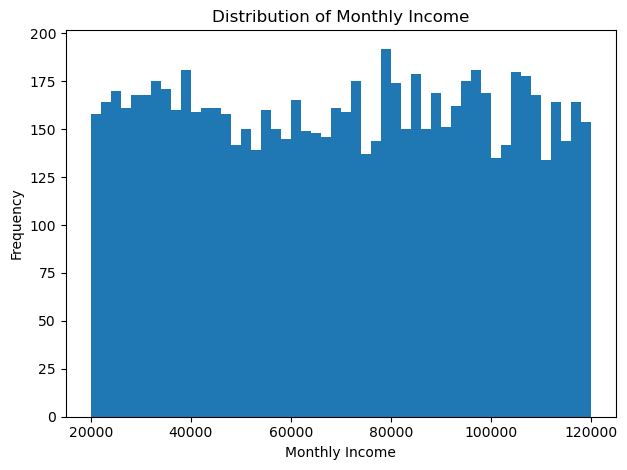

In [9]:
plt.figure()
plt.hist(df["Monthly_Income"], bins=50)
plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.title("Distribution of Monthly Income")
plt.tight_layout()
plt.savefig("Histogram_Monthly_Income.png", dpi=300)
plt.show()

Boxplot - Loan Amount by Credit Default

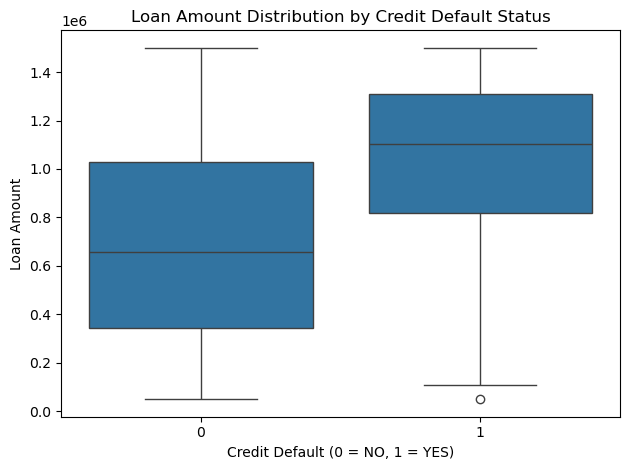

In [10]:
plt.figure()
sns.boxplot(x="Credit_Default", y="Loan_Amount", data=df)
plt.xlabel("Credit Default (0 = NO, 1 = YES)")
plt.ylabel("Loan Amount")
plt.title("Loan Amount Distribution by Credit Default Status")
plt.tight_layout()
plt.savefig("Boxplot_LoanAmount_by_CreditDefault.png", dpi=300)
plt.show()

Step 8: Percentile Analysis

In [11]:
df[numeric_cols].quantile([0.25, 0.50, 0.75, 0.90, 0.95])

,Age,Monthly_Income,Loan_Amount,Loan_Tenure_Months,Interest_Rate,EMI,Credit_Utilisation,Delayed_Payments
0.25,31.0,44054.75,410375.00,24.0,11.250,16643.661262,0.30,1.0
0.50,40.0,70363.50,772169.00,36.0,13.460,31811.401145,0.50,3.0
0.75,50.0,94997.00,1127078.75,48.0,15.760,49479.362400,0.70,4.0
0.90,56.0,109461.20,1347240.90,60.0,17.111,78722.516757,0.82,5.0
0.95,58.0,114994.75,1426568.35,60.0,17.560,109293.135275,0.86,5.0


Task 2: Correlations & Covariance Analysis

Step 1: Select Variables for Relationship Analysis

In [12]:
corr_cols = [
    "Monthly_Income",
    "Loan_Amount",
    "Loan_Tenure_Months",
    "Interest_Rate",
    "EMI",
    "Credit_Utilisation",
    "Delayed_Payments"
]

df_corr = df[corr_cols]


Step 2: Correlation Matriz (Pearson)

In [13]:
correlation_matrix = df_corr.corr()
correlation_matrix

,Monthly_Income,Loan_Amount,Loan_Tenure_Months,Interest_Rate,EMI,Credit_Utilisation,Delayed_Payments
Monthly_Income,1.000000,-0.011259,-0.001556,0.003137,-0.016957,-0.007499,-0.002805
Loan_Amount,-0.011259,1.000000,-0.034899,-0.008789,0.703620,0.004395,-0.007809
Loan_Tenure_Months,-0.001556,-0.034899,1.000000,0.013467,-0.582103,-0.003676,-0.005640
Interest_Rate,0.003137,-0.008789,0.013467,1.000000,0.045018,-0.000644,-0.003276
EMI,-0.016957,0.703620,-0.582103,0.045018,1.000000,-0.004583,0.006489
Credit_Utilisation,-0.007499,0.004395,-0.003676,-0.000644,-0.004583,1.000000,-0.007152
Delayed_Payments,-0.002805,-0.007809,-0.005640,-0.003276,0.006489,-0.007152,1.000000


Step 3: Covariance Matrix

In [14]:
covariance_matrix = df_corr.cov()
covariance_matrix

,Monthly_Income,Loan_Amount,Loan_Tenure_Months,Interest_Rate,EMI,Credit_Utilisation,Delayed_Payments
Monthly_Income,8.401405e+08,-1.359564e+08,-759.955343,236.971448,-1.479382e+07,-50.280839,-138.467300
Loan_Amount,-1.359564e+08,1.735556e+11,-245029.303585,-9541.695424,8.822743e+09,423.570858,-5539.916016
Loan_Tenure_Months,-7.599553e+02,-2.450293e+05,284.028848,0.591458,-2.952755e+05,-0.014332,-0.161858
Interest_Rate,2.369714e+02,-9.541695e+03,0.591458,6.790903,3.530979e+03,-0.000388,-0.014538
EMI,-1.479382e+07,8.822743e+09,-295275.491801,3530.978839,9.059247e+08,-31.907006,332.598773
Credit_Utilisation,-5.028084e+01,4.235709e+02,-0.014332,-0.000388,-3.190701e+01,0.053508,-0.002817
Delayed_Payments,-1.384673e+02,-5.539916e+03,-0.161858,-0.014538,3.325988e+02,-0.002817,2.899862


Step 4: Correlation Heatmap

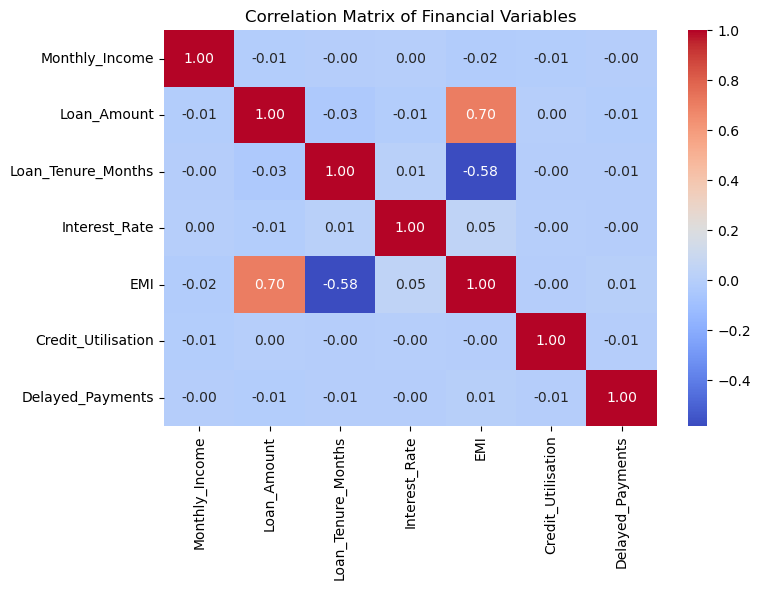

In [15]:
import os

#Ensure the directory exists
output_dir = r"D:\Python_workshop\Visuals"
os.makedirs(output_dir, exist_ok=True)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Financial Variables")
plt.tight_layout()

#Save the heatmap
plt.savefig(os.path.join(output_dir, "Correlation_Heatmap.png"), dpi=300)
plt.show()

Step 5: Pairwise Correlation Focus (Business-Relevant Pairs)

In [17]:
df_corr[["Monthly_Income", "EMI"]].corr()

,Monthly_Income,EMI
Monthly_Income,1.000000,-0.016957
EMI,-0.016957,1.000000


In [18]:
df_corr[["Loan_Amount", "EMI"]] .corr()

,Loan_Amount,EMI
Loan_Amount,1.00000,0.70362
EMI,0.70362,1.00000


In [20]:
df_corr[["Credit_Utilisation", "Delayed_Payments"]].corr()

,Credit_Utilisation,Delayed_Payments
Credit_Utilisation,1.000000,-0.007152
Delayed_Payments,-0.007152,1.000000


Task 3: Simple Linear Regression

Objective: Examine how Loan Amount influences EMI.


Step 1: Select Variables

In [22]:
X = df[["Loan_Amount"]]   # Independent variable
y = df["EMI"]             # Dependent variable

Step 2: Import Required Library


In [23]:
from sklearn.linear_model import LinearRegression

 Step 3: Build and Fit the Model

In [24]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Step 4: Extract Regression Coefficients

In [26]:
intercept = model.intercept_
slope = model.coef_[0]
intercept, slope

(np.float64(-809.653819306659), np.float64(0.05083525260215455))

 Step 5: Model Fit (R-squared)

In [27]:
r_squared = model.score(X, y)
r_squared

0.4950812592396051

Step 6: Predicted EMI

In [28]:
df["Predicted_EMI"] = model.predict(X)
df[["Loan_Amount", "EMI", "Predicted_EMI"]].head()

,Loan_Amount,EMI,Predicted_EMI
0,918004,38428.66744,45857.311410
1,209772,10478.11140,9854.158790
2,122146,11324.96997,5399.668945
3,1206130,45454.34919,60504.269402
4,996924,51283.43210,49869.229546


Step 7: Scatter Plot with Regression Line

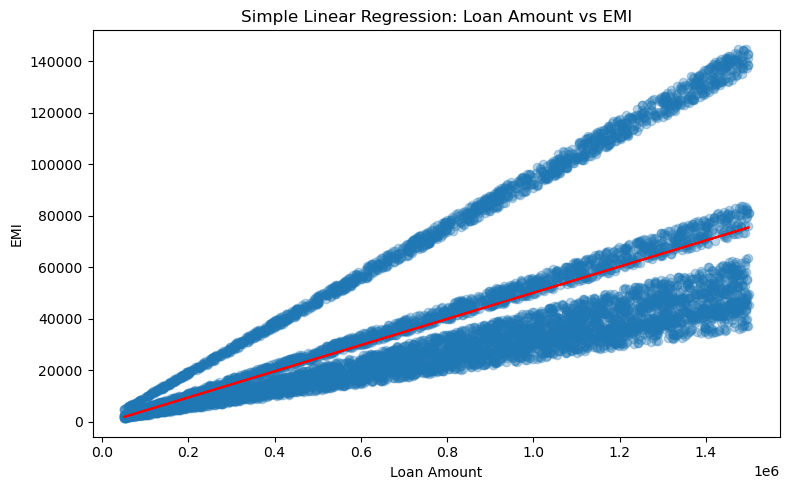

In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(df["Loan_Amount"], df["EMI"], alpha=0.3)
plt.plot(df["Loan_Amount"], df["Predicted_EMI"], color="red")
plt.xlabel("Loan Amount")
plt.ylabel("EMI")
plt.title("Simple Linear Regression: Loan Amount vs EMI")
plt.tight_layout()
plt.show()

Task 4: Simple Time Series Analysis

Step 1: Ensure Date Variable is in Datetime Format

In [41]:
df["Observation_Month"] = pd.to_datetime(df["Observation_Month"])

Step 2: Aggregate Data by Month (Default Rate)

In [43]:
monthly_default_rate = (
df.groupby("Observation_Month")["Credit_Default"]
.mean()
.reset_index()
)
monthly_default_rate.head()

,Observation_Month,Credit_Default
0,2019-01-31,0.275362
1,2019-02-28,0.147287
2,2019-03-31,0.181818
3,2019-04-30,0.219697
4,2019-05-31,0.206107


Step 3: Set Time Index

In [44]:
monthly_default_rate.set_index("Observation_Month", inplace=True)
monthly_default_rate

,Credit_Default
Observation_Month,
2019-01-31,0.275362
2019-02-28,0.147287
2019-03-31,0.181818
2019-04-30,0.219697
2019-05-31,0.206107
2019-06-30,0.225225
2019-07-31,0.224806
2019-08-31,0.229630
2019-09-30,0.201493


Step 4: Plot Time Series (Default Rate Over Time)

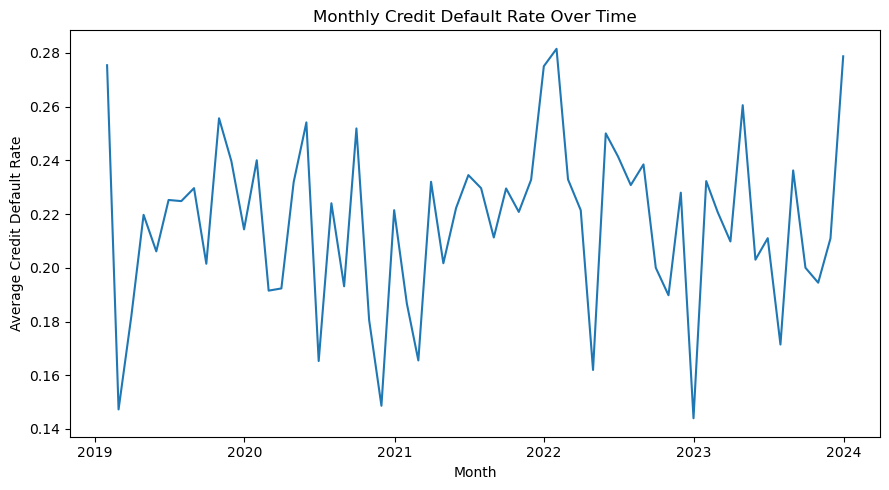

In [45]:
plt.figure(figsize=(9, 5))
plt.plot(monthly_default_rate.index, monthly_default_rate["Credit_Default"])
plt.xlabel("Month")
plt.ylabel("Average Credit Default Rate")
plt.title("Monthly Credit Default Rate Over Time")
plt.tight_layout()
plt.show()

Step 5: Rolling Mean (Trend Smoothing)

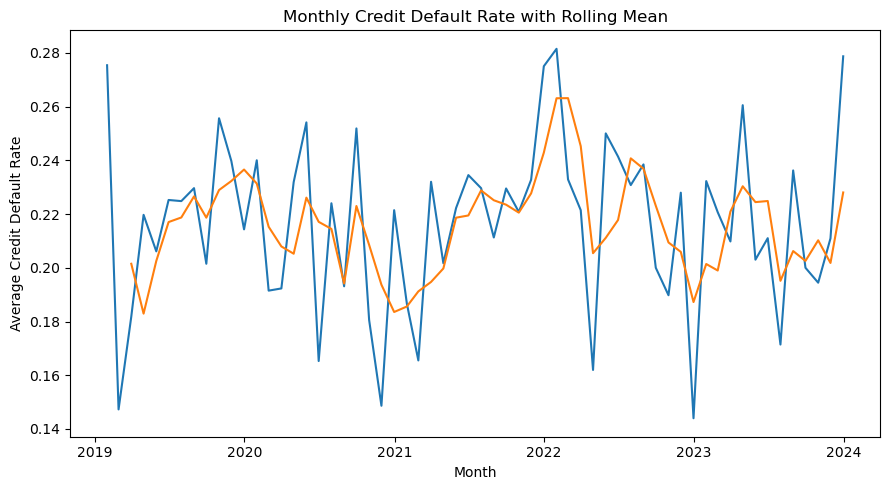

In [48]:
monthly_default_rate["Rolling_Mean_3"] = (
monthly_default_rate["Credit_Default"].rolling(window=3).mean()
)
plt.figure(figsize=(9, 5))
plt.plot(monthly_default_rate.index, monthly_default_rate["Credit_Default"], alpha= 1)
plt.plot(monthly_default_rate.index, monthly_default_rate["Rolling_Mean_3"])
plt.xlabel("Month")
plt.ylabel("Average Credit Default Rate")
plt.title("Monthly Credit Default Rate with Rolling Mean")
plt.tight_layout()
plt.show()


Step 6: Basic Time Series Summary

In [49]:
monthly_default_rate.describe()

,Credit_Default,Rolling_Mean_3
count,60.000000,58.000000
mean,0.216772,0.215820
std,0.031944,0.017795
min,0.144000,0.182934
25%,0.198611,0.202543
50%,0.221429,0.217437
75%,0.233278,0.226439
max,0.281481,0.263119
